# Aprendizaxe automático - Práctica 3

## Redes convolucionais

**Luis Barba Cepedello, Rubén Pérez Sangiao, Daniel Piqueras Valle**

## Implementación dunha arquitectura MLP modular

In [1]:
import torch
from torch import nn

# Clase que define un MLP xenérico
class MLP(nn.Module):
    def __init__(self, input_neurons, output_neurons, hidden_layers):
        # Parámetros:
        # input_neurons: Número de neuronas da capa de entrada
        # output_neurons: Número de neuronas da capa de saída
        # hidden_layers: Lista onde cada elemento representa o número de neuronas dunha capa oculta

        # Chamamos ao constructor da clase nai
        super(MLP, self).__init__()

        # Lista onde iremos engadindo cada unha das capas
        layers = []

        # O número de entradas da primeira capa é 'input_neurons'
        current_input = input_neurons

        # Iteramos sobre a lista de capas ocultas para construír a rede paso a paso
        for hidden_neurons in hidden_layers:
            # Engadimos a capa lineal
            layers.append(nn.Linear(in_features=current_input, out_features=hidden_neurons))

            # Engadimos a función de activación RELU (hai que ter en conta que non se aplica á última)
            layers.append(nn.ReLU())

            # A saída desta capa será a entrada da seguinte
            current_input = hidden_neurons

        # Unha vez engadidas todas as capas ocultas, engadimos a capa de saída
        layers.append(nn.Linear(in_features=current_input, out_features=output_neurons))

        # nn.Sequential permítenos empaquetar a lista de capas nun único módulo que as executará en orde secuencial cando se faga o forward
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Definimos o método forward, que é chamado cando se pasa unha imaxe pola rede

        # Aplicamos o aplanamento
        x = torch.flatten(x, start_dim=1)

        # Pasamos os datos pola nosa secuencia de capas
        predicted_probs = self.network(x)
        return predicted_probs

## Implementación dunha arquitectura CNN modular

In [2]:
# Clase que define unha rede neuronal convolucional xenérica.
class CNN(nn.Module):
    def __init__(self,
                 input_channels,
                 conv_layers,
                 first_conv_filters,
                 conv_kernel_size,
                 batch_norm,
                 hidden_mlp_layers,
                 output_neurons,
                 image_size=160): # Engadimos image_size para poder facer logo o flatten

        # Chamamos ao constructor da clase pai
        super(CNN, self).__init__()

        ### CONSTRUCIÓN DA PARTE CONVOLUCIONAL ###
        conv_modules = []
        in_c = input_channels
        out_c = first_conv_filters

        # Iteramos para crear as capas convolucionais
        for i in range(conv_layers):
            # Añadimos a capa convolucional
            # Empregamos o seguinte padding: conv_kernel_size // 2 para mantener as proporcións antes do pooling
            conv_modules.append(nn.Conv2d(in_channels=in_c,
                                          out_channels=out_c,
                                          kernel_size=conv_kernel_size,
                                          padding=conv_kernel_size // 2))

            # Normalización por lotes
            # Normalizamos antes de aplicar a ReLU, pero perfectamente podería facerse ao revés
            # Escollemos facelo así porque era o que recomendaban Sergey Ioffe e Christian Szegedy, os creadores da técnica
            if batch_norm:
                conv_modules.append(nn.BatchNorm2d(out_c))

            # Función de activación ReLU
            conv_modules.append(nn.ReLU())

            # Capa de Pooling
            # Asumimos un MaxPooling estándar de 2x2
            conv_modules.append(nn.MaxPool2d(kernel_size=2, stride=2))

            # Para a proxima capa a entrada son os filtros de salida actuales
            in_c = out_c
            # Doble número de filtros para a siguiente capa convolucional
            out_c *= 2

        self.cnn = nn.Sequential(*conv_modules)

        ### CONSTRUCIÓN DA PARTE MLP ###
        # Creamos un tensor falso del tamaño de nuestras imágenes para pasarlo por la red convolucional
        # y así descubrir automáticamente cuántas características salen tras todos los MaxPoolings.
        dummy_tensor = torch.zeros(1, input_channels, image_size, image_size)
        dummy_output = self.cnn(dummy_tensor)
        flattened_size = dummy_output.view(-1).shape[0]

        mlp_modules = []
        current_input = flattened_size

        # Iteramos sobre as capas ocultas do MLP
        for hidden_neurons in hidden_mlp_layers:
            mlp_modules.append(nn.Linear(in_features=current_input, out_features=hidden_neurons))
            mlp_modules.append(nn.ReLU())
            current_input = hidden_neurons

        # Capa final de salida (sin función de activación)
        mlp_modules.append(nn.Linear(in_features=current_input, out_features=output_neurons))

        self.mlp = nn.Sequential(*mlp_modules)

    def forward(self, x):
        x = self.cnn(x)

        # Aplanado final unidimensional para pasarllo ao MLP
        x = torch.flatten(x, start_dim=1)
        x = self.mlp(x)

        return x

#

In [8]:
import copy

# Función xenérica para adestrar unha época
def train(dataloader, model, loss_fn, optimizer, device="cpu"):
    # Obtemos o número total de lotes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de adestramento
    model.train()

    loss = 0.0
    n_batch = 0

    # Iteramos sobre os lotes
    for batch_imgs, batch_labels in dataloader:
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

        # Obtemos as predicións para o lote actual
        pred = model(batch_imgs)
        # Calculamos a perda
        loss = loss_fn(pred, batch_labels)
        # Poñemos a cero os gradientes dos parámetros do modelo
        optimizer.zero_grad()
        # Realizamos a retropropagación para calcular os gradientes de cada parámetro
        loss.backward()
        # Actualizamos os parámetros do modelo utilizando os gradientes calculados
        optimizer.step()

        # Calculamos o loss acumulado
        loss += loss.item() * batch_imgs.size(0)

        # Cada 100 lotes, imprimimos a perda e o progreso
        if n_batch % 100 == 0:
            loss, imgs_processed = loss.item(), n_batch * len(batch_imgs)
            print(f"perda: {loss:>7f}  [{imgs_processed:>5d}/{num_images:>5d}]")

        n_batch += 1

    return loss / len(dataloader.dataset)

# Función xenérica para avaliar o modelo (tanto para validación como para test)
def evaluate(dataloader, model, loss_fn, device="cpu"):
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

            # Obtemos as predicións para o lote actual
            pred = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            loss += loss_fn(pred, batch_labels).item() * batch_imgs.size(0)

            _, predicted = torch.max(pred, 1)
            correct += (predicted == batch_labels).sum().item()
            total += batch_labels.size(0)

    val_loss = loss / total
    val_acc = (correct / total) * 100
    return val_loss, val_acc

## Adestramento e optimización de MLPs e CNNs nun problema real

In [9]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# Mirando a documentacion vimos que as imaxes non son cadradas asi que as redimensionamos
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

# Particion de train, que dividiremos en train e val
full_train_dataset = torchvision.datasets.Imagenette(
    root='./data',
    split='train',
    size='160px', # Pedimos la versión de baja resolución
    download=True,
    transform=transform
)

train_proportion = 0.8
train_size = int(train_proportion * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Para que la partición sea reproducible
)

# Particion de val, que usaremos para test
test_dataset = torchvision.datasets.Imagenette(
    root='./data',
    split='val',
    size='160px',
    download=True,
    transform=transform
)

print(f"Tamaño adestramento: {len(train_dataset)} imaxes.")
print(f"Tamaño validación: {len(val_dataset)} imaxes.")
print(f"Tamaño test: {len(test_dataset)} imaxes.")

batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

imaxes, etiquetas = next(iter(train_loader))
print(f"Forma tensor imaxes (batch_size, canles, alto, ancho): {imaxes.shape}")

Tamaño adestramento: 7575 imaxes.
Tamaño validación: 1894 imaxes.
Tamaño test: 3925 imaxes.
Forma del tensor de imágenes (batch_size, canales, alto, ancho): torch.Size([8, 3, 160, 160])


In [11]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Adestrando con {device}")

mlp_model = MLP(input_neurons=76800, output_neurons=10, hidden_layers=[128, 64]).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=0.001)

# Variables para gardar o historial e Early Stopping
mlp_val_losses = []
mlp_val_accs = []
max_epochs = 30
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_mlp_wts = copy.deepcopy(mlp_model.state_dict())

print("--- Iniciando adestramento do MLP ---")
for epoch in range(max_epochs):
    # Adestramos e avaliamos
    train_loss = train(train_loader, mlp_model, loss_fn, optimizer_mlp, device)
    val_loss, val_acc = evaluate(val_loader, mlp_model, loss_fn, device)

    mlp_val_losses.append(val_loss)
    mlp_val_accs.append(val_acc)

    print(f"Época {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_mlp_wts = copy.deepcopy(mlp_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"-> Parada temperá na época {epoch+1}!")
            break

# Restauramos os mellores pesos obtidos
mlp_model.load_state_dict(best_mlp_wts)
print("MLP adestrado e mellor modelo cargado.")

Adestrando no dispositivo: cuda
--- Iniciando adestramento do MLP ---
Época 01 | Train Loss: 2.2892 | Val Loss: 2.1257 | Val Acc: 20.49%
Época 02 | Train Loss: 2.1343 | Val Loss: 2.2509 | Val Acc: 16.53%
Época 03 | Train Loss: 2.0373 | Val Loss: 2.0049 | Val Acc: 27.93%
Época 04 | Train Loss: 1.9634 | Val Loss: 1.9997 | Val Acc: 30.31%
Época 05 | Train Loss: 1.9378 | Val Loss: 1.9413 | Val Acc: 30.46%
Época 06 | Train Loss: 1.9101 | Val Loss: 1.9368 | Val Acc: 31.94%
Época 07 | Train Loss: 1.8780 | Val Loss: 1.9012 | Val Acc: 33.95%
Época 08 | Train Loss: 1.8597 | Val Loss: 1.8649 | Val Acc: 34.85%
Época 09 | Train Loss: 1.8244 | Val Loss: 1.8621 | Val Acc: 34.58%
Época 10 | Train Loss: 1.8108 | Val Loss: 1.9897 | Val Acc: 29.94%
Época 11 | Train Loss: 1.7842 | Val Loss: 1.8755 | Val Acc: 34.27%
Época 12 | Train Loss: 1.7881 | Val Loss: 1.9045 | Val Acc: 33.90%
Época 13 | Train Loss: 1.7580 | Val Loss: 1.8447 | Val Acc: 35.85%
Época 14 | Train Loss: 1.7320 | Val Loss: 1.8563 | Val Acc:

In [6]:
# 1. Instanciamos a CNN
cnn_model = CNN(input_channels=3,
                conv_layers=3,
                first_conv_filters=16,
                conv_kernel_size=3,
                batch_norm=True,
                hidden_mlp_layers=[128],
                output_neurons=10,
                image_size=160).to(device)

optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

# Variables para gardar o historial e Early Stopping
cnn_val_losses = []
cnn_val_accs = []
best_val_loss = float('inf')
patience_counter = 0
best_cnn_wts = copy.deepcopy(cnn_model.state_dict())

print("--- Iniciando adestramento da CNN ---")
for epoch in range(max_epochs):
    train_loss = train(train_loader, cnn_model, loss_fn, optimizer_cnn, device)
    val_loss, val_acc = evaluate(val_loader, cnn_model, loss_fn, device)

    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)

    print(f"Época {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_cnn_wts = copy.deepcopy(cnn_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"-> Parada temperá na época {epoch+1}!")
            break

cnn_model.load_state_dict(best_cnn_wts)
print("CNN adestrada e mellor modelo cargado.")

--- Iniciando adestramento da CNN ---
Época 01 | Train Loss: 2.0621 | Val Loss: 1.6250 | Val Acc: 45.72%
Época 02 | Train Loss: 1.3990 | Val Loss: 1.4787 | Val Acc: 51.00%
Época 03 | Train Loss: 1.1089 | Val Loss: 1.2060 | Val Acc: 59.82%
Época 04 | Train Loss: 0.9043 | Val Loss: 1.1933 | Val Acc: 63.73%
Época 05 | Train Loss: 0.7280 | Val Loss: 1.2687 | Val Acc: 62.41%
Época 06 | Train Loss: 0.5942 | Val Loss: 1.2217 | Val Acc: 63.04%
Época 07 | Train Loss: 0.4734 | Val Loss: 1.4554 | Val Acc: 60.24%
Época 08 | Train Loss: 0.3731 | Val Loss: 1.3063 | Val Acc: 65.21%
Época 09 | Train Loss: 0.2521 | Val Loss: 1.3741 | Val Acc: 62.72%
-> Parada temperá na época 9!
CNN adestrada e mellor modelo cargado.


 RESULTADOS FINAIS NO CONXUNTO DE TEST
MLP -> Test Loss: 1.7976 | Accuracy: 39.90%
CNN -> Test Loss: 1.2260 | Accuracy: 62.98%

Parámetros do MLP: 9,839,434
Parámetros da CNN: 3,302,026



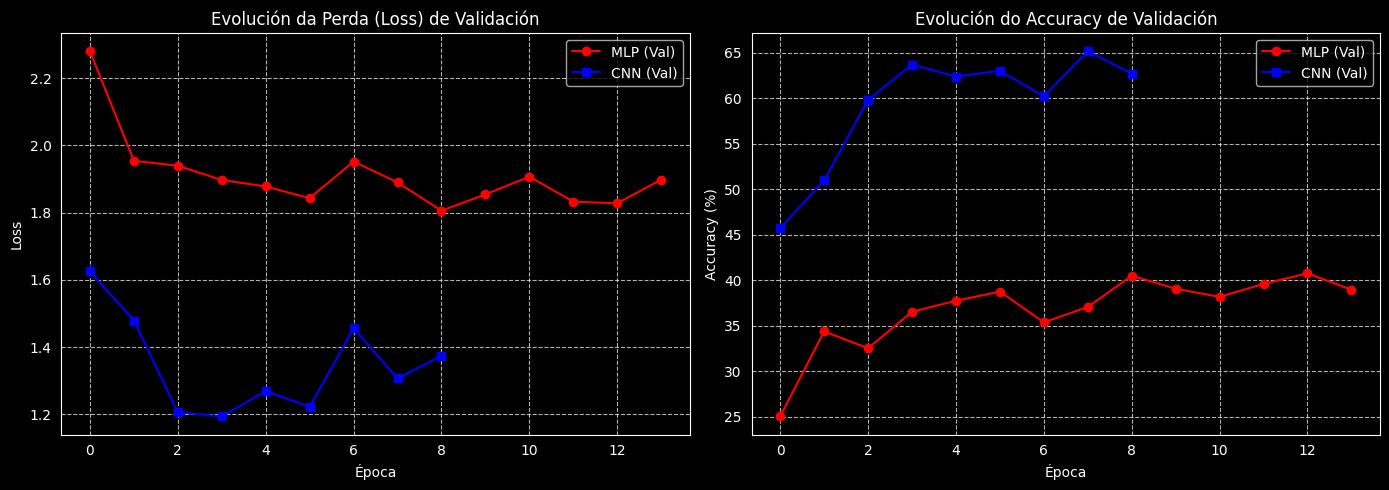

In [7]:
import matplotlib.pyplot as plt

# --- 1. AVALIACIÓN NO CONXUNTO DE TEST ---
print("="*50)
print(" RESULTADOS FINAIS NO CONXUNTO DE TEST")
print("="*50)

# Avaliamos usando a función xenérica do principio da práctica
test_loss_mlp, test_acc_mlp = evaluate(test_loader, mlp_model, loss_fn, device)
test_loss_cnn, test_acc_cnn = evaluate(test_loader, cnn_model, loss_fn, device)

print(f"MLP -> Test Loss: {test_loss_mlp:.4f} | Accuracy: {test_acc_mlp:.2f}%")
print(f"CNN -> Test Loss: {test_loss_cnn:.4f} | Accuracy: {test_acc_cnn:.2f}%\n")


# --- 2. CÁLCULO DE COMPLEXIDADE ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_mlp = count_parameters(mlp_model)
params_cnn = count_parameters(cnn_model)

print(f"Parámetros do MLP: {params_mlp:,}")
print(f"Parámetros da CNN: {params_cnn:,}\n")


# --- 3. GRÁFICAS COMPARATIVAS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax1.plot(mlp_val_losses, label='MLP (Val)', color='red', marker='o')
ax1.plot(cnn_val_losses, label='CNN (Val)', color='blue', marker='s')
ax1.set_title('Evolución da Perda (Loss) de Validación')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Accuracy
ax2.plot(mlp_val_accs, label='MLP (Val)', color='red', marker='o')
ax2.plot(cnn_val_accs, label='CNN (Val)', color='blue', marker='s')
ax2.set_title('Evolución do Accuracy de Validación')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()